In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Naveen Shaji\OneDrive\Desktop\DATA ANALYTICS\Financial risk detection\creditcard.csv\creditcard.csv')

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [4]:
print("\nMissing Values:\n", df.isnull().sum().sum())


Missing Values:
 0


In [5]:
fraud_count = df['Class'].value_counts()

In [6]:
print("\nClass Distribution:\n", fraud_count)


Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
# VISUALISING THE IMBALANCE

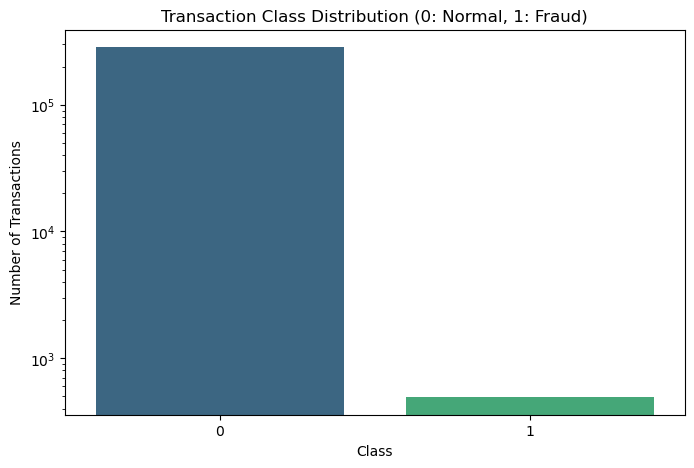

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_count.index, y=fraud_count.values, hue=fraud_count.index, palette='viridis', legend=False)
plt.title('Transaction Class Distribution (0: Normal, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.yscale('log') 
plt.show()

In [9]:
from sklearn.preprocessing import RobustScaler

In [10]:
rob_scaler = RobustScaler()

In [11]:
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

In [12]:
df.drop(['Time','Amount'], axis=1, inplace=True)

In [13]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

In [14]:
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

In [15]:
print("Data Scaling Complete!")
print(df.head())

Data Scaling Complete!
   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       1.783274    -0.994983 -1.359807 -0.072781  2.536347  1.378155   
1      -0.269825    -0.994983  1.191857  0.266151  0.166480  0.448154   
2       4.983721    -0.994972 -1.358354 -1.340163  1.773209  0.379780   
3       1.418291    -0.994972 -0.966272 -0.185226  1.792993 -0.863291   
4       0.670579    -0.994960 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26       V27      

In [ ]:
#SCALING is done

In [ ]:
#performing Random Under Sampling to increase the aacuracy.

In [16]:
import numpy as np

In [17]:
df = df.sample(frac=1)

In [18]:
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492] # Take only 492 non-fraud cases

In [19]:
normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

In [20]:
new_df = normal_distributed_df.sample(frac=1, random_state=42)

In [21]:
print('Distribution of the Classes in the subsample dataset')
print(new_df['Class'].value_counts()/len(new_df))

Distribution of the Classes in the subsample dataset
Class
0    0.5
1    0.5
Name: count, dtype: float64


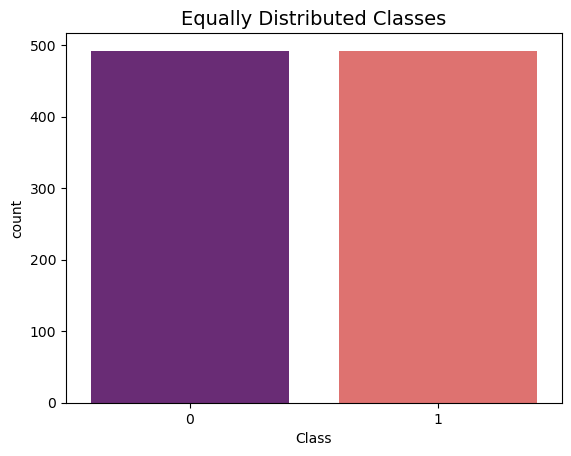

In [22]:
sns.countplot(x='Class', data=new_df, hue='Class', palette='magma', legend=False)
plt.title('Equally Distributed Classes', fontsize=14)
plt.show()

In [ ]:
#data is levelled . So we can use heatmap to understand (V1, V2, etc.) are "guilty" of being associated with fraud.

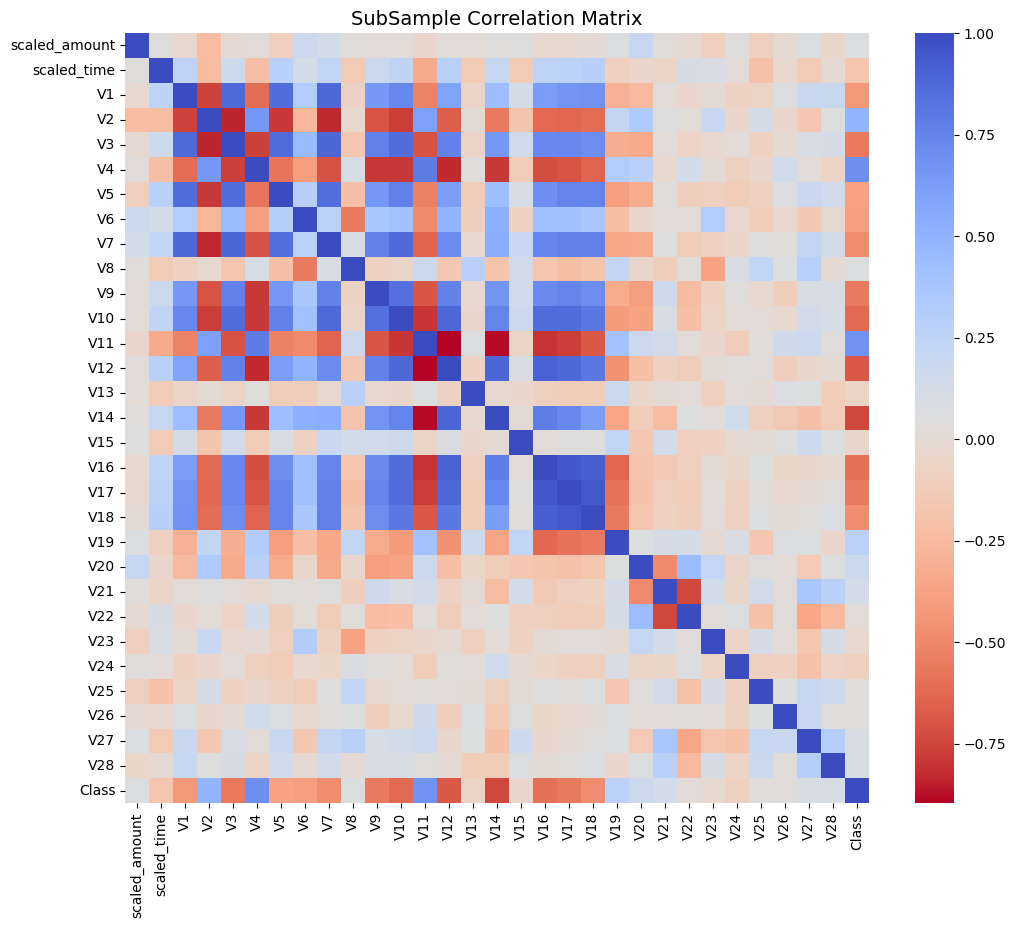

In [23]:
plt.figure(figsize=(12,10))
sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20})
plt.title('SubSample Correlation Matrix', fontsize=14)
plt.show()

In [ ]:
#Training


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
# X is our features, y is our target (Class)
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [26]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Convert to arrays for the model
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [28]:
print("Data split complete. Ready for Model Building!")

Data split complete. Ready for Model Building!


In [ ]:
#model we can use are Logistic Regression, Random Forest, 
#I am Trying a latest model - XGBoost . This model can work great for fraud Detection.

In [29]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [30]:
# Initialize the XGBoost Classifier
# 'scale_pos_weight' is a special parameter that tells XGBoost 
# to pay extra attention to the minority (Fraud) class.
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=1, # Since we balanced the data in Step 4, we use 1
    use_label_encoder=False,
    eval_metric='logloss'
)

In [32]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=1, 
    eval_metric='logloss' # Notice: use_label_encoder is gone
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [33]:
# Create a copy of the test data
results_df = pd.DataFrame(X_test, columns=X.columns)

# Add the Actual and Predicted labels
results_df['Actual_Class'] = y_test
results_df['Predicted_Class'] = y_pred
results_df['Fraud_Probability'] = y_prob  # The 'score' the AI gave it

# Save to CSV
results_df.to_csv('fraud_detection_results.csv', index=False)
print("File ready for Tableau!")

NameError: name 'y_pred' is not defined

In [34]:
# 1. Generate the predictions again to make sure they are in memory
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] 

# 2. Create the results DataFrame
import pandas as pd
results_df = pd.DataFrame(X_test, columns=X.columns)

# 3. Add the Actual and Predicted labels
results_df['Actual_Class'] = y_test
results_df['Predicted_Class'] = y_pred
results_df['Fraud_Probability'] = y_prob  # This is the "Risk Score" for Tableau

# 4. Save to CSV
results_df.to_csv('fraud_detection_results.csv', index=False)

print("Success! 'fraud_detection_results.csv' has been created.")

Success! 'fraud_detection_results.csv' has been created.


In [35]:
import pandas as pd
verify_df = pd.read_csv(r'C:\Users\Naveen Shaji\OneDrive\Desktop\DATA ANALYTICS\Financial risk detection\fraud_detection_results.csv')
print(verify_df[['Actual_Class', 'Predicted_Class', 'Fraud_Probability']].head())

   Actual_Class  Predicted_Class  Fraud_Probability
0             1                1           0.975493
1             1                0           0.008034
2             0                0           0.002273
3             1                1           0.999428
4             1                1           0.999334
